In [ ]:

# Plot the confusion matrix (Fig. 2b, and Appendix A3) for the 18 target classes
# using the fractionnal approach and the environmental images

In [1]:
import pickle
import numpy as np
import pandas as pd

from collections import defaultdict

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import gridspec

In [ ]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent.parent))
from config1 import CLASSIFICATION_DATA, get_predictions_scores, get_18score_vector, classes54, classes18


In [3]:
p_model_outputs = CLASSIFICATION_DATA / "4.MODEL_PREDICTIONS"

p_global_weights =CLASSIFICATION_DATA /"globalweights_f1scores_18cl.csv"


In [ ]:
classes18_it = [
    '$\\it{Quercus~deciduous}$', '$\\it{Quercus~ilex}$', '$\\it{Buxus}$', '$\\it{Phillyrea}$',
    '$\\it{Fraxinus}$', '$\\it{Olea}$', 'Cupressaceae', '$\\it{Pistacia}$', 'Poaceae',
    '$\\it{Plantago}$', '$\\it{Vitis}$ fertile', '$\\it{Vitis}$ sterile', 'Pinaceae', 'Other taxa',
    'Indeterminate (covered)', 'Indeterminate (blurry)', 'Non-pollen', '$\\it{Lycopodium}$'
]

class_sum_other = ['Other', 'Acacia', 'Acer', 'Alnus', 'Amarantaceae', 'Artemisia', 'Betulaceae', 'Brassicaceae', 'Carduus', 'Caryophyllaceae', 'Cichorioideae', 'Cyperaceae', 
               'Echium', 'Ericaceae', 'Fagus', 'Gallium', 'Juglans', 'Lamiaceae', 'Liliaceae', 'Moraceae', 'Morphotype1', 
               'Morphotype2', 'Myrtaceae', 'Platanus', 'PopulusSp', 'Ranunculaceae', 'Rhamnus', 'Rosaceae', 'Rumex', 'Salix', 'Sanguisorba', 'Tilia', 'Ulmus', 'Urtica',
                 'ViburnumSambucusTp', 'XanthiumAmbrosia']

In [5]:
# export weights per model for weights

df_w = pd.read_csv(p_global_weights)
print(len(list(df_w["classe"])))

weights_dict = {
    model: df_group.set_index("classe")["f1score"].to_dict()
    for model, df_group in df_w.groupby("cval")
}
sum_f1_by_model = df_w.groupby("cval")["f1score"].sum().to_dict()
print(weights_dict)


df_w.head()

180
{'fold1': {'Buxus': 0.988235294117647, 'Cupressaceae': 0.956989247311828, 'Fraxinus': 0.87719298245614, 'IndetBlurry': 0.953488372093023, 'IndetCovered': 0.893617021276596, 'Lycopodium': 0.990033222591362, 'NonPollen': 0.937062937062937, 'Olea': 0.939393939393939, 'Other': 0.947890818858561, 'Phillyrea': 0.862745098039216, 'Pinaceae': 0.994818652849741, 'Pistacia': 0.909090909090909, 'Plantago': 0.985507246376812, 'Poaceae': 0.989473684210526, 'QuercusDeciduous': 0.782608695652174, 'QuercusIlex': 0.943661971830986, 'VitisF': 0.982456140350877, 'VitisS': 0.914285714285714}, 'fold10': {'Buxus': 0.976190476190476, 'Cupressaceae': 0.966666666666667, 'Fraxinus': 0.84, 'IndetBlurry': 0.98876404494382, 'IndetCovered': 0.888888888888889, 'Lycopodium': 1.0, 'NonPollen': 0.957746478873239, 'Olea': 0.984126984126984, 'Other': 0.944444444444444, 'Phillyrea': 0.872727272727273, 'Pinaceae': 1.0, 'Pistacia': 0.978723404255319, 'Plantago': 0.957746478873239, 'Poaceae': 0.989583333333333, 'QuercusD

,cval,classe,f1score,counter
0,fold1,Buxus,0.988235,84
1,fold1,Cupressaceae,0.956989,91
2,fold1,Fraxinus,0.877193,28
3,fold1,IndetBlurry,0.953488,44
4,fold1,IndetCovered,0.893617,49


In [ ]:
# Get confusion matrix

dict_cm= defaultdict(lambda: np.zeros(len(classes18)))

for idx in [1,2,3,4,5,6,7,8,9,10]:
    cval_id = f'fold{idx}'
    true, predscores, filenames = get_predictions_scores(cval_id, p_model_outputs, classes54, refenv="env")

    for e, filename_i in enumerate(filenames):
        true_i = true[e]
        vector_k_18, class_true = get_18score_vector(cval_id, true_i, predscores[e], weights_dict, sum_f1_by_model, classes18, classes54, class_sum_other)
        dict_cm[class_true]+= vector_k_18

conf_matrix1 = np.array([dict_cm[cls] for cls in classes18])
row_sums = conf_matrix1.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1  # avoid division by zero
conf_matrix100 = (conf_matrix1 / row_sums) * 100


In [8]:

cm_normalized = conf_matrix100.copy()
cm = conf_matrix1.copy()
sx=10
sy=8
cm_total_true = conf_matrix1.sum(axis=1)
cm_total_pred = conf_matrix1.sum(axis=0)

print(cm_total_true)
print(cm_total_pred)

cm_deviation = (cm_total_pred - cm_total_true) / cm_total_true * 100  # percentage deviation from true totals


[ 121.  677.  837.  263.  279.  326.  914.  230.  956.  345.  572.  183.
  954. 2037.  487.  440. 1420. 1499.]
[ 113.30738646  702.39222383  846.28414956  275.16877912  276.21603295
  325.79863437  932.36222667  234.23823277  960.19556253  347.06536375
  572.91721561  184.17523234  963.48982818 2018.83530202  447.89608869
  435.40863587 1406.92380918 1497.32529611]


In [9]:
greys = plt.get_cmap('Greys') # Greys')
colors = [greys(i) for i in np.linspace(0, 0.1, 65)]  #  [(1, 1, 1)] * 50  # white for 0-50
colors += [greys(i) for i in np.linspace(0.1, 1, 35)]  # light to dark blue for 50-100
new_cmap = mcolors.LinearSegmentedColormap.from_list("custom_blues", colors, N=100)

/tmp/ipykernel_15857/2708320453.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


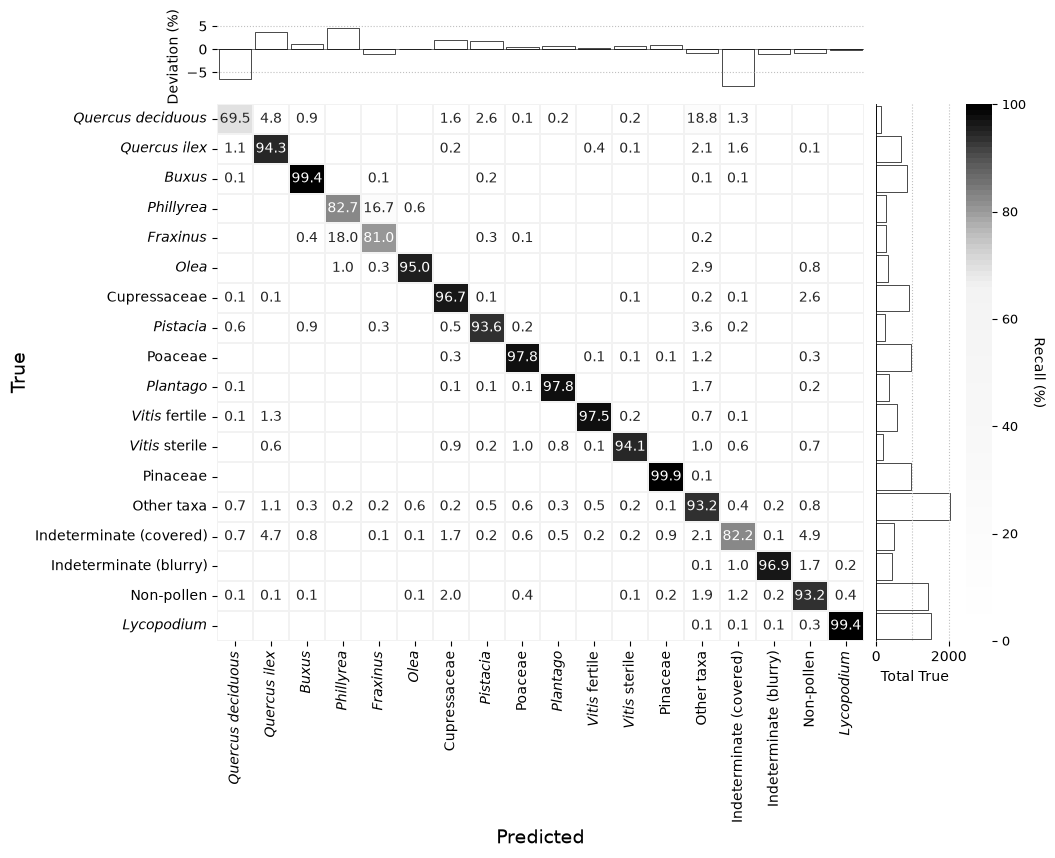

In [11]:
# Figure 2.b

fig = plt.figure(figsize=(sx, sy))
gs = gridspec.GridSpec(
    2, 3,
    width_ratios=[10, 1.2, 0.4],
    height_ratios=[1.2, 10],
    wspace=0.05, hspace=0.05
)

ax_main = plt.subplot(gs[1, 0])
ax_right = plt.subplot(gs[1, 1], sharey=ax_main)
ax_top = plt.subplot(gs[0, 0], sharex=ax_main)
ax_cbar = plt.subplot(gs[1, 2]) 

annot_vals = np.where(cm_normalized < 0.049, "", np.round(cm_normalized, 1).astype(str))
sns.heatmap(
    cm_normalized,
    annot=annot_vals,
    fmt='', # '.1f',
    cmap=new_cmap,
    xticklabels=classes18_it,
    yticklabels=classes18_it,
    cbar=True,
    linewidths=0.1,         
    linecolor='#f2f2f2', 
    vmin=0,
    vmax=100,
    ax=ax_main,
    cbar_ax=ax_cbar
)
ax_main.set_xticklabels(labels=classes18_it, fontsize=10)
ax_main.set_yticklabels(labels=classes18_it, fontsize=10)
ax_main.set_xlabel('Predicted', fontsize=14)
ax_main.set_ylabel('True', fontsize=14)
ax_main.set_title('')

x_positions =  np.arange(len(cm_deviation)) + 0.5 
ax_top.bar(x_positions, cm_deviation, color='white', width=0.9, edgecolor='black',linewidth=0.5, ) 
ax_top.set_ylabel("Deviation (%)", fontsize=10)
ax_top.tick_params(axis='x', bottom=False, labelbottom=False)
ax_top.axhline(0, color='black', linestyle='-', linewidth=0.4)
ax_top.axhline(5, color='silver', linestyle=':', linewidth=0.8)
ax_top.axhline(-5, color='silver', linestyle=':', linewidth=0.8)
ax_top.grid(False)
sns.despine(ax=ax_top, left=True, bottom=True)

y_positions = np.arange(len(cm_total_true)) + 0.5
ax_right.barh(y_positions, cm_total_true, color='white', height=0.9, edgecolor='black',linewidth=0.5, )  # silver
ax_right.set_xlabel("Total True", fontsize=10)
ax_right.tick_params(axis='y', left=False, labelleft=False)
ax_right.axvline(1000, color='silver', linestyle=':', linewidth=0.8)
ax_right.axvline(2000, color='silver', linestyle=':', linewidth=0.8)
ax_right.axvline(0, color='black', linestyle='-', linewidth=1.2)
ax_right.grid(False)
sns.despine(ax=ax_right, left=True, bottom=True)

ax_cbar.set_ylabel("Recall (%)", rotation=-90, va="bottom")
ax_cbar.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig(CLASSIFICATION_DATA / "Fig2b_confusion_matrix_recall.pdf",  bbox_inches="tight")
plt.show()


### Supporting Information - percentages precision

In [12]:
col_sums = conf_matrix1.sum(axis=0, keepdims=True)
col_sums[col_sums == 0] = 1  
conf_matrix100 = (conf_matrix1 / col_sums) * 100

cm_normalized = conf_matrix100.copy()
cm = conf_matrix1.copy()
sx=10
sy=8
cm_total_true = conf_matrix1.sum(axis=1)
cm_total_pred = conf_matrix1.sum(axis=0)



/tmp/ipykernel_15857/361043880.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


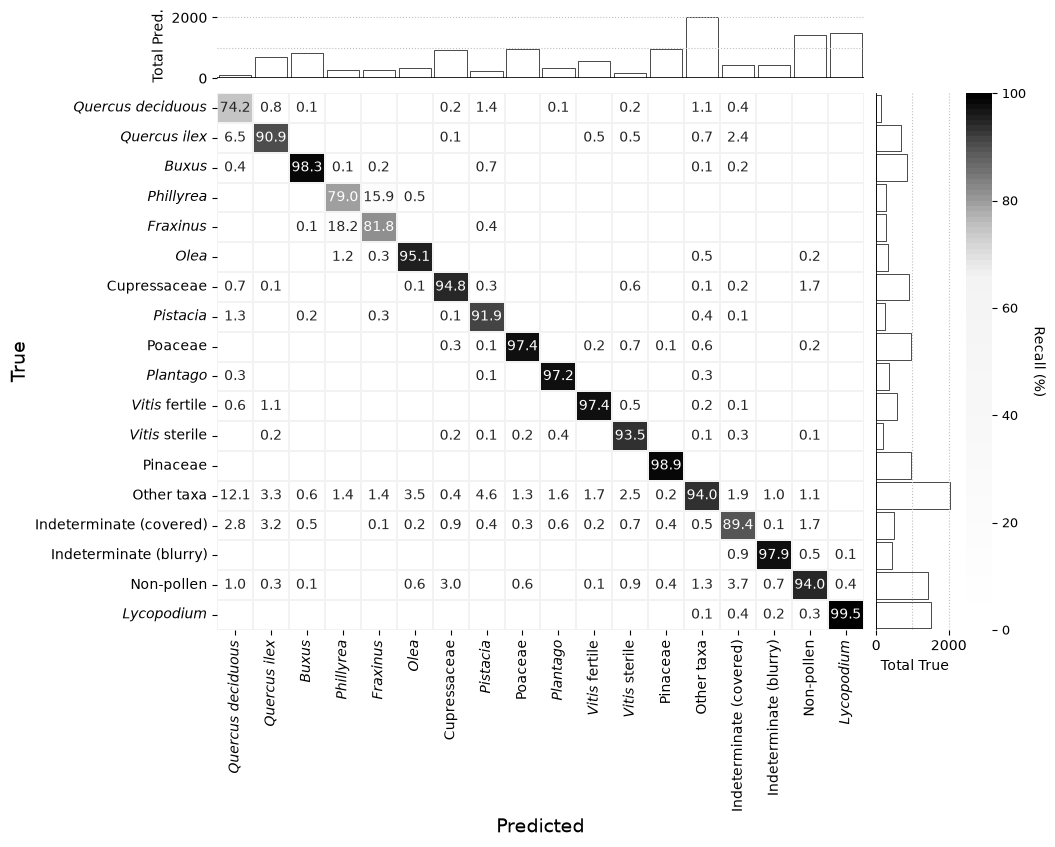

In [14]:
# Figue Appendix A3

fig = plt.figure(figsize=(sx, sy))
gs = gridspec.GridSpec(
    2, 3, 
    width_ratios=[10, 1.2, 0.4],
    height_ratios=[1.2, 10],
    wspace=0.05, hspace=0.05
)

ax_main = plt.subplot(gs[1, 0])
ax_right = plt.subplot(gs[1, 1], sharey=ax_main)
ax_top = plt.subplot(gs[0, 0], sharex=ax_main)
ax_cbar = plt.subplot(gs[1, 2])  

annot_vals = np.where(cm_normalized < 0.049, "", np.round(cm_normalized, 1).astype(str))

sns.heatmap(
    cm_normalized,
    annot=annot_vals,
    fmt='', # '.1f',
    cmap=new_cmap,
    xticklabels=classes18_it,
    yticklabels=classes18_it,
    cbar=True,
    linewidths=0.1,         
    linecolor='#f2f2f2', 
    vmin=0,
    vmax=100,
    ax=ax_main,
    cbar_ax=ax_cbar
)
ax_main.set_xticklabels(labels=classes18_it, fontsize=10)
ax_main.set_yticklabels(labels=classes18_it, fontsize=10)
ax_main.set_xlabel('Predicted', fontsize=14)
ax_main.set_ylabel('True', fontsize=14)
ax_main.set_title('')

# 4. Plot top bar: total per predicted class
x_positions =  np.arange(len(cm_total_pred)) + 0.5
ax_top.bar(x_positions, cm_total_pred, color='white', width=0.9, edgecolor='black',linewidth=0.5, ) 
ax_top.set_ylabel("Total Pred.", fontsize=10)
ax_top.tick_params(axis='x', bottom=False, labelbottom=False)
ax_top.axhline(1000, color='silver', linestyle=':', linewidth=0.8)
ax_top.axhline(2000, color='silver', linestyle=':', linewidth=0.8)
ax_top.axhline(0, color='black', linestyle='-', linewidth=1.2)
ax_top.grid(False)
sns.despine(ax=ax_top, left=True, bottom=True)

y_positions = np.arange(len(cm_total_true)) + 0.5
ax_right.barh(y_positions, cm_total_true, color='white', height=0.9, edgecolor='black',linewidth=0.5)
ax_right.set_xlabel("Total True", fontsize=10)
ax_right.tick_params(axis='y', left=False, labelleft=False)
ax_right.axvline(1000, color='silver', linestyle=':', linewidth=0.8)
ax_right.axvline(2000, color='silver', linestyle=':', linewidth=0.8)
ax_right.axvline(0, color='black', linestyle='-', linewidth=1.2)
ax_right.grid(False)
sns.despine(ax=ax_right, left=True, bottom=True)

ax_cbar.set_ylabel("Recall (%)", rotation=-90, va="bottom")
ax_cbar.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig(CLASSIFICATION_DATA / "FigApp_A3_confusion_matrix_precision.pdf",  bbox_inches="tight")

plt.show()



In [ ]:
# end